In [22]:
# Install packages
!pip install swig mediapy
!pip install mujoco==3.1.4
!pip install opencv-python

# Imports and Functions

In [23]:
# Imports
import os
os.environ.setdefault('MUJOCO_GL', 'egl')
import cv2
import mujoco
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.patches import Ellipse
from IPython.display import HTML
import mediapy as media


In [24]:
def render_episode(policy, env):
	frames = []
	score = 0
	state = env.reset()[0]
	terminated = truncated = False
	while not terminated and not truncated:
		frame = env.render()
		frames.append(frame)
		action = policy(state)
		state, reward, terminated, truncated, _ = env.step(action)
		score += reward
	env.close()
	print(f"Finished episode. Cummulative Return: {score}")
	media.show_video(frames, fps=100, loop=True)

# Perception in Robotics
Perception in robotics refers to the ability of robots to sense and interpret their environment using various sensors such as cameras, LiDAR, radar, and touch sensors. This capability is crucial for enabling robots to navigate, interact with, and make decisions about their surroundings. Perception allows robots to perform tasks such as object recognition, localization, and mapping, which are essential for applications ranging from industrial automation to autonomous driving. In the context of learning-based control of robotic systems, perception plays a pivotal role by providing the necessary sensory data that informs decision-making processes. Learning from raw input data, such as images, involves directly processing high-dimensional sensory inputs to extract meaningful features, which can be computationally intensive and data-hungry. In contrast, learning from dense state representations involves using pre-processed, compact representations of the environment, which can simplify the learning process and improve efficiency by focusing on the most relevant aspects of the sensory data.

## Noisy Sensor Data
Noisy sensors are a common challenge in robotics. Sensors are used to gather information about the environment, such as position, distance, or object detection. However, these sensors are not perfect and can introduce errors or inaccuracies in their measurements. This noise can be caused by various factors, including sensor limitations, environmental conditions, or interference. The presence of noise in sensor data can lead to incorrect or unreliable information, which can significantly impact the performance and reliability of robotic systems. To mitigate the effects of noisy sensors, various techniques are employed, such as sensor fusion, filtering algorithms, or calibration procedures. These methods aim to improve the accuracy and reliability of sensor measurements, enabling robots to make more informed decisions and operate effectively in real-world scenarios.

## Partial Observation
Partial observation is a significant challenge in robotics, where robots often have limited access to complete and accurate information about their environment. Due to the constraints of sensors and the complexity of real-world scenarios, robots may only be able to observe a subset of the relevant data. This partial observation can lead to incomplete or distorted perceptions of the environment, making it difficult for robots to make informed decisions and navigate effectively. To address this issue, robotics researchers and engineers employ various techniques such as sensor fusion, probabilistic modeling, and machine learning algorithms to infer and estimate the missing information. By combining multiple sources of data and leveraging advanced algorithms, robots can enhance their perception capabilities and overcome the limitations of partial observation, enabling them to operate more autonomously and effectively in complex real-world environments.

## Kalman Filter
The Kalman filter is a mathematical algorithm used for estimating the state of a system based on incomplete and noisy measurements. It is widely used in robotics for sensor fusion, where multiple sensors provide different measurements of the same physical quantity.

In the context of robotics, the Kalman filter is used to estimate the state of a robot, such as its position, velocity, or orientation, by combining measurements from various sensors, such as GPS, IMU, or vision sensors. The filter takes into account the uncertainty in the measurements and the dynamics of the system to provide an optimal estimate of the state.

The important parameters of the Kalman filter include:

1. Initial state: This is the initial estimate of the state of the system. It represents the best guess of the state before any measurements are available.

2. Initial covariance: This is the initial estimate of the uncertainty in the state. It represents the confidence in the initial state estimate.

3. Measurement matrix: This matrix relates the measurements to the state variables. It defines how the measurements are related to the state of the system.

4. Measurement noise covariance: This matrix represents the uncertainty in the measurements. It captures the noise and errors in the sensor measurements.

5. Transition matrix: This matrix describes the dynamics of the system. It defines how the state variables evolve over time.

6. Process noise covariance: This matrix represents the uncertainty in the system dynamics. It captures the noise and errors in the system model.

The Kalman filter algorithm consists of two main steps: prediction and update. In the prediction step, the filter uses the transition matrix and process noise covariance to predict the next state of the system. In the update step, the filter combines the predicted state with the measurements using the measurement matrix and measurement noise covariance to obtain an updated estimate of the state.

By iteratively performing the prediction and update steps, the Kalman filter continuously refines its estimate of the state, taking into account the measurements and the dynamics of the system. This allows the filter to provide an accurate and robust estimate of the state, even in the presence of noise and uncertainties.


In [25]:
# A simple Kalman filter implementation
class KalmanFilter:
    def __init__(self, initial_state, initial_covariance, measurement_matrix, measurement_noise_covariance, transition_matrix, process_noise_covariance):
        self.state = initial_state
        self.covariance = initial_covariance
        self.measurement_matrix = measurement_matrix
        self.measurement_noise_covariance = measurement_noise_covariance
        self.transition_matrix = transition_matrix
        self.process_noise_covariance = process_noise_covariance

    def predict(self):
        self.state = self.transition_matrix@self.state
        self.covariance = self.transition_matrix@self.covariance@self.transition_matrix.T + self.process_noise_covariance

    def update(self, measurement):
        innovation = measurement - self.measurement_matrix@self.state
        innovation_covariance = self.measurement_matrix@self.covariance@self.measurement_matrix.T + self.measurement_noise_covariance
        kalman_gain = self.covariance@self.measurement_matrix.T@np.linalg.inv(innovation_covariance)

        self.state = self.state + kalman_gain@innovation
        self.covariance = (np.identity(len(self.state)) - kalman_gain @ self.measurement_matrix) @ self.covariance @ \
            (np.identity(len(self.state)) - kalman_gain @ self.measurement_matrix).T + kalman_gain @ self.measurement_noise_covariance @ kalman_gain.T

In [26]:
# We here visualize the uncertainty propagation of a one-dimensional particle.
# In addition to dealing with the noise of the position measurements, we estimate the velocity
# Define the Kalman filter parameters
initial_state = np.array([0, 0])
initial_covariance = np.array([[2, 0], [0, 2]])
measurement_matrix = np.array([[1, 0]])
measurement_noise_covariance = np.array([[0.5]])
transition_matrix = np.array([[1, 1], [0, 1]])
process_noise_covariance = np.array([[0.001, 0], [0, 0.01]])
kalman_filter = KalmanFilter(initial_state, initial_covariance, measurement_matrix, measurement_noise_covariance, transition_matrix, process_noise_covariance)

# Generate noisy measurements
measurements = (np.linspace(1, 20, 20) + np.random.normal(loc=0, scale=0.5**2, size=20)).reshape(-1, 1)
estimations = np.zeros((len(measurements)+1, 2))
estimations[0] = kalman_filter.state
covariances = np.zeros((len(measurements)+1, 2, 2))
covariances[0] = kalman_filter.covariance

# Perform uncertainty propagation
for i, measurement in enumerate(measurements):
    kalman_filter.predict()
    kalman_filter.update(measurement)
    estimations[i+1] = kalman_filter.state
    covariances[i+1] = kalman_filter.covariance

def ellipse(cov_matrix):
    pearson = cov_matrix[0, 1]/np.sqrt(cov_matrix[0, 0] * cov_matrix[1, 1])
    ell_radius_x = np.sqrt(1 + pearson)
    ell_radius_y = np.sqrt(1 - pearson)
    angle = 0.5 * np.arctan2(2 * cov_matrix[0, 1], (cov_matrix[0, 0] - cov_matrix[1, 1]))
    width = ell_radius_x * 2 * np.sqrt(cov_matrix[0, 0])
    height = ell_radius_y * 2 * np.sqrt(cov_matrix[1, 1])
    angle = np.degrees(angle)
    return width, height, angle

# Render the uncertainty propagation as a video
fig, ax = plt.subplots()
xdata, ydata = [], []
traj, = ax.plot([], [], 'b')
s, = ax.plot([], [],'o', c='b')
c = Ellipse((0, 0), 1, 1, fill=True, color='b', alpha=0.2, lw=.5)
ax.plot([], [], 'r', label='noisy measurements')
ax.plot([], [], 'b', label='state estimate')
ax.legend()
plt.close()

def init():
    ax.set_xlim(-1, 21)
    ax.set_ylim(-1, 2)
    ax.set_xlabel('position')
    ax.set_ylabel('velocity')
    ax.add_patch(c)
    return traj, s, c
def update(i):
    xdata.append(estimations[i,0])
    ydata.append(estimations[i,1])
    traj.set_data(xdata, ydata)
    s.set_data([estimations[i,0]], [estimations[i,1]])
    c.center = (estimations[i,0], estimations[i,1])
    cov = covariances[i]
    c.width, c.height, c.angle = ellipse(cov)
    if i>0:
        ax.axvline(measurements[i-1], c = 'r', linewidth=0.7)
    return traj, s, c
ani = FuncAnimation(fig, update, len(estimations),
                    init_func=init, blit=True, interval=1000)
HTML(ani.to_html5_video())

In [27]:
# Two dimensional measurements
# Initialize a Kalman Filter that takes in noisy measurements of a 2D position and estimates the position and velocity
initial_state = np.array([0, 0, 0, 0])
initial_covariance = np.identity(4)
measurement_matrix = np.array([[1, 0, 0, 0], [0, 1, 0, 0]])
measurement_noise_covariance = np.identity(2) * 0.1**2
transition_matrix = np.array([[1, 0, 1, 0], [0, 1, 0, 1], [0, 0, 1, 0], [0, 0, 0, 1]])
process_noise_covariance = np.diag([1e-5,1e-5,1e-4,1e-4])

kalman_filter = KalmanFilter(initial_state, initial_covariance, measurement_matrix, measurement_noise_covariance, transition_matrix, process_noise_covariance)

# Generate ground truth trajectory
ground_truth = np.zeros((200, 2))
for i in range(200):
    t = i / 200 * 2 * np.pi
    x = np.sin(t) + np.sin(2 * t)
    y = np.cos(t) - np.cos(2 * t)
    ground_truth[i] = [x, y]

# Generate noise measurements
measurements = np.random.normal(0, 0.1, (200, 2)) + ground_truth
estimations = np.zeros((len(measurements), 4))
covariances = np.zeros((len(measurements), 4, 4))

# Run the Kalman filter over the noise measurements
for i, measurement in enumerate(measurements):
    kalman_filter.predict()
    kalman_filter.update(measurement)
    estimations[i] = kalman_filter.state
    covariances[i] = kalman_filter.covariance

# Render the uncertainty propagation as a video
fig, ax = plt.subplots()
xest, yest = [], []
xmeas, ymeas = [], []
traj, = ax.plot([], [], 'b')
s, = ax.plot([], [],'o', c='b', label='state estimate')
meas, = ax.plot([],[], 'o', c='r', label='measurements')
gt, = ax.plot(ground_truth[:,0], ground_truth[:,1],
              '--', c='g', label='ground truth')
ax.legend()
plt.close()

def init():
    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)
    ax.set_xlabel('x position')
    ax.set_ylabel('y position')
    return traj, meas, s, gt
def update(i):
    xest.append(estimations[i,0])
    yest.append(estimations[i,1])
    xmeas.append(measurements[i,0])
    ymeas.append(measurements[i,1])
    traj.set_data(xest, yest)
    meas.set_data(xmeas,ymeas)
    s.set_data([estimations[i,0]], [estimations[i,1]])
    return traj, meas, s, gt
ani = FuncAnimation(fig, update, len(estimations),
                    init_func=init, blit=True, interval=100)
HTML(ani.to_html5_video())

### Tasks
1. Play around with the parameters of the Kalman filter to understand what they are doing.
2. The Kalman filter features a forward model that is implemented via the transition matrix. What do we assume here?
3. We can imagine the measurements we observe to be noisy GPS data and we use our filter to remove the noise. How can the Kalman filter help us if we stop receiving measurements alltogether?

### Answers
2. The transition matrix F = [[1, 1], [0, 1]] assumes constant velocity motion — that is, position updates as x_{t+1} = x_t + v_t, and velocity stays constant v_{t+1} = v_t. There is no acceleration modeled. This is a linear, time-invariant motion model.
3. If GPS measurements stop, the Kalman filter continues running the predict step only — it propagates the state forward using the transition matrix (the motion model). This means it keeps estimating where the object should be based on its last known velocity. However, without updates, the covariance grows over time, meaning uncertainty increases the longer we go without measurements. The filter essentially "dead-reckons" — useful for short gaps, but degrades over time.

# Object Detection & Tracking
Object detection is a core perception tool in robotics. In manipulation, robots use it to localize grasp targets, pick and place objects accurately, and handle cluttered scenes. In locomotion, it helps identify obstacles and free space so the robot can plan safer paths and react to dynamic environments.

In this section, we focus on a practical perception setting: detect a moving red cylinder even when it is partially occluded by obstacles in the scene.

We compare two classical detection methods:
1. Color-based segmentation.
2. Background differencing against a reference image.

To evaluate their robustness, we run both methods under two scene conditions:
- `static_light`: constant illumination, with a small static red distractor.
- `dynamic_light`: moving light direction (shifting shadows) plus an additional green distractor that does not exist in the reference background.

After comparing failure modes of each detection approach, we continue with color-based detections for Kalman tracking in the `dynamic_light` scene.


static_light:
  video: object_detection_data/static_light/static_light_scene.mp4
  background image: object_detection_data/static_light/static_light_background.png
  ground truth: object_detection_data/static_light/static_light_gt.npz
dynamic_light:
  video: object_detection_data/dynamic_light/dynamic_light_scene.mp4
  background image: object_detection_data/dynamic_light/dynamic_light_background.png
  ground truth: object_detection_data/dynamic_light/dynamic_light_gt.npz


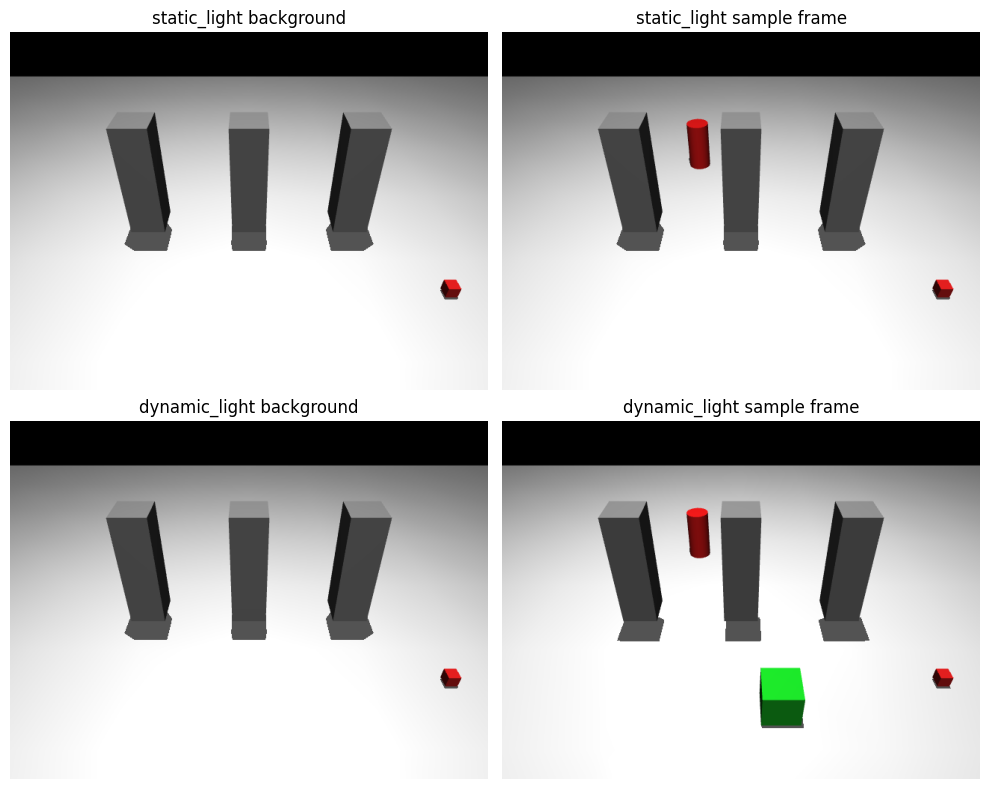

static_light video preview:


This browser does not support the video tag.


dynamic_light video preview:


This browser does not support the video tag.


In [28]:
# Generate reproducible MuJoCo scenes for object-detection experiments
np.random.seed(0)

# Layout:
# - Three static occluders near the center.
# - A small static red cube (background distractor).
# - A moving red cylinder (target) behind the occluders.
# - A green box that is not part of the reference background image.
OCCLUDER_Y = 0.05
OCCLUDER_Z = 0.15
OCCLUDER_HALF_X = 0.030
OCCLUDER_HALF_Y = 0.030
OCCLUDER_HALF_Z = 0.10

LEFT_OCCLUDER_X = -0.18
MID_OCCLUDER_X = 0.00
RIGHT_OCCLUDER_X = 0.18

NOISE_CUBE_X = 0.33
NOISE_CUBE_Y = -0.08
NOISE_CUBE_Z = 0.015
NOISE_CUBE_HALF = 0.01

GREEN_BOX_X = 0.06
GREEN_BOX_Y = -0.13
GREEN_BOX_Z = 0.03
GREEN_BOX_HALF_X = 0.03
GREEN_BOX_HALF_Y = 0.03
GREEN_BOX_HALF_Z = 0.03

OBJECT_Z = 0.05
OBJECT_RADIUS = 0.025
OBJECT_HALF_HEIGHT = 0.060
TRACK_Y = 0.17  # larger y than occluders -> behind occluders from camera viewpoint
X_LEFT = -0.20
X_RIGHT = 0.50

BASE_LIGHT_POS = np.array([0.0, -0.15, 2.10], dtype=np.float64)
LIGHT_SWEEP_RADIUS_X = 0.90
LIGHT_SWEEP_RADIUS_Y = 0.55
LIGHT_SWEEP_HEIGHT_DELTA = 0.25


def moving_light_position(frame_idx, num_frames):
    phase = 2.0 * np.pi * frame_idx / max(1, 5 * (num_frames - 1))
    # Start at BASE_LIGHT_POS, then move the light to create shadow motion over time.
    x = BASE_LIGHT_POS[0] + LIGHT_SWEEP_RADIUS_X * (np.cos(phase) - 1.0)
    y = BASE_LIGHT_POS[1] + LIGHT_SWEEP_RADIUS_Y * np.sin(phase)
    z = BASE_LIGHT_POS[2] + LIGHT_SWEEP_HEIGHT_DELTA * np.sin(2.0 * phase)
    return np.array([x, y, z], dtype=np.float64)


def get_detection_scene_xml(include_red_object=True, include_green_object=False, light_pos=BASE_LIGHT_POS):
    red_object_block = f"""
        <body name='red_obj' pos='{X_LEFT} {TRACK_Y} {OBJECT_Z}'>
          <joint name='red_x' type='slide' axis='1 0 0'/>
          <joint name='red_y' type='slide' axis='0 1 0'/>
          <geom type='cylinder' size='{OBJECT_RADIUS} {OBJECT_HALF_HEIGHT}' rgba='0.95 0.10 0.10 1'/>
        </body>
    """ if include_red_object else ""

    green_object_block = f"""
        <geom name='green_box_distractor' type='box'
              pos='{GREEN_BOX_X} {GREEN_BOX_Y} {GREEN_BOX_Z}'
              size='{GREEN_BOX_HALF_X} {GREEN_BOX_HALF_Y} {GREEN_BOX_HALF_Z}'
              rgba='0.10 0.85 0.15 1'/>
    """ if include_green_object else ""

    lx, ly, lz = light_pos
    return f"""
    <mujoco model='single_object_tracking'>
      <option timestep='0.02' gravity='0 0 -9.81'/>
      <worldbody>
        <light name='scene_light' pos='{lx} {ly} {lz}' diffuse='0.75 0.75 0.75' castshadow='true'/>
        <camera name='oblique_top' pos='0 -0.50 0.50' xyaxes='1 0 0 0 0.611 0.792' fovy='50'/>
        <geom name='floor' type='plane' pos='0 0 0' size='1.0 1.0 0.1' rgba='0.95 0.95 0.95 1'/>
        <geom name='occluder_left' type='box' pos='{LEFT_OCCLUDER_X} {OCCLUDER_Y} {OCCLUDER_Z}' size='{OCCLUDER_HALF_X} {OCCLUDER_HALF_Y} {OCCLUDER_HALF_Z}' rgba='0.55 0.55 0.55 1'/>
        <geom name='occluder_mid' type='box' pos='{MID_OCCLUDER_X} {OCCLUDER_Y} {OCCLUDER_Z}' size='{OCCLUDER_HALF_X} {OCCLUDER_HALF_Y} {OCCLUDER_HALF_Z}' rgba='0.55 0.55 0.55 1'/>
        <geom name='occluder_right' type='box' pos='{RIGHT_OCCLUDER_X} {OCCLUDER_Y} {OCCLUDER_Z}' size='{OCCLUDER_HALF_X} {OCCLUDER_HALF_Y} {OCCLUDER_HALF_Z}' rgba='0.55 0.55 0.55 1'/>
        <geom name='red_cube_distractor' type='box' pos='{NOISE_CUBE_X} {NOISE_CUBE_Y} {NOISE_CUBE_Z}' size='{NOISE_CUBE_HALF} {NOISE_CUBE_HALF} {NOISE_CUBE_HALF}' rgba='0.90 0.12 0.12 1'/>
        {green_object_block}
        {red_object_block}
      </worldbody>
    </mujoco>
    """


def save_video_cv2(frames_rgb, video_path, fps=30):
    h, w = frames_rgb[0].shape[:2]
    writer = cv2.VideoWriter(video_path, cv2.VideoWriter_fourcc(*'mp4v'), fps, (w, h))
    final_path = video_path

    if not writer.isOpened():
        fallback_path = os.path.splitext(video_path)[0] + '.avi'
        writer = cv2.VideoWriter(fallback_path, cv2.VideoWriter_fourcc(*'MJPG'), fps, (w, h))
        final_path = fallback_path

    if not writer.isOpened():
        raise RuntimeError('Could not open OpenCV VideoWriter for MP4 or AVI output.')

    for frame_rgb in frames_rgb:
        writer.write(cv2.cvtColor(frame_rgb, cv2.COLOR_RGB2BGR))
    writer.release()
    return final_path


def render_background_frame(width, height):
    bg_model = mujoco.MjModel.from_xml_string(
        get_detection_scene_xml(include_red_object=False, include_green_object=False, light_pos=BASE_LIGHT_POS)
    )
    bg_data = mujoco.MjData(bg_model)
    bg_renderer = mujoco.Renderer(bg_model, width=width, height=height)
    mujoco.mj_forward(bg_model, bg_data)
    bg_renderer.update_scene(bg_data, camera='oblique_top')
    return bg_renderer.render().copy()


def generate_scene_dataset(
    num_frames=180,
    fps=30,
    width=640,
    height=480,
    include_green_object=False,
    apply_lighting_variation=False,
    out_dir='object_detection_data/scene',
    prefix='scene',
):
    model = mujoco.MjModel.from_xml_string(
        get_detection_scene_xml(
            include_red_object=True,
            include_green_object=include_green_object,
            light_pos=BASE_LIGHT_POS,
        )
    )
    data = mujoco.MjData(model)
    renderer = mujoco.Renderer(model, width=width, height=height)

    os.makedirs(out_dir, exist_ok=True)
    video_path = os.path.join(out_dir, f'{prefix}_scene.mp4')
    gt_path = os.path.join(out_dir, f'{prefix}_gt.npz')
    bg_path = os.path.join(out_dir, f'{prefix}_background.png')

    background_rgb = render_background_frame(width, height)
    cv2.imwrite(bg_path, cv2.cvtColor(background_rgb, cv2.COLOR_RGB2BGR))

    red_x_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_JOINT, 'red_x')
    red_y_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_JOINT, 'red_y')
    red_body_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, 'red_obj')
    light_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_LIGHT, 'scene_light')
    red_x_qpos = model.jnt_qposadr[red_x_id]
    red_y_qpos = model.jnt_qposadr[red_y_id]

    frames_rgb = []
    times = np.arange(num_frames) / fps
    world_xy = np.zeros((num_frames, 2), dtype=np.float32)

    def smoothstep(a):
        return a * a * (3.0 - 2.0 * a)

    half = num_frames // 2
    for i in range(num_frames):
        if i < half:
            alpha = smoothstep(i / max(1, half - 1))
            x = X_LEFT + alpha * (X_RIGHT - X_LEFT)
        else:
            alpha = smoothstep((i - half) / max(1, num_frames - half - 1))
            x = X_RIGHT - alpha * (X_RIGHT - X_LEFT)

        model.light_pos[light_id] = moving_light_position(i, num_frames) if apply_lighting_variation else BASE_LIGHT_POS
        data.qpos[red_x_qpos] = x
        data.qpos[red_y_qpos] = TRACK_Y

        mujoco.mj_forward(model, data)
        world_xy[i] = data.xpos[red_body_id, :2]
        renderer.update_scene(data, camera='oblique_top')
        frames_rgb.append(renderer.render().copy())

    saved_video_path = save_video_cv2(frames_rgb, video_path, fps=fps)
    np.savez(gt_path, times=times, world_xy=world_xy, color_names=np.array(['red']))
    return frames_rgb, background_rgb, saved_video_path, gt_path, bg_path


SCENE_CONFIGS = {
    'static_light': dict(include_green_object=False, apply_lighting_variation=False),
    'dynamic_light': dict(include_green_object=True, apply_lighting_variation=True),
}

scene_data = {}
for scene_name, scene_cfg in SCENE_CONFIGS.items():
    frames, background, video_path, gt_path, bg_path = generate_scene_dataset(
        out_dir=f'object_detection_data/{scene_name}',
        prefix=scene_name,
        **scene_cfg,
    )
    scene_data[scene_name] = {
        'frames': frames,
        'background': background,
        'video_path': video_path,
        'gt_path': gt_path,
        'background_path': bg_path,
    }
    print(f'{scene_name}:')
    print(f'  video: {video_path}')
    print(f'  background image: {bg_path}')
    print(f'  ground truth: {gt_path}')

static_scene = scene_data['static_light']
dynamic_scene = scene_data['dynamic_light']

frames_static_rgb = static_scene['frames']
background_static_rgb = static_scene['background']
frames_dynamic_rgb = dynamic_scene['frames']
background_dynamic_rgb = dynamic_scene['background']
scene_dynamic_gt_path = dynamic_scene['gt_path']

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for row, scene_name in enumerate(['static_light', 'dynamic_light']):
    scene = scene_data[scene_name]
    axes[row, 0].imshow(scene['background'])
    axes[row, 0].set_title(f'{scene_name} background')
    axes[row, 0].axis('off')
    axes[row, 1].imshow(scene['frames'][40])
    axes[row, 1].set_title(f'{scene_name} sample frame')
    axes[row, 1].axis('off')

plt.tight_layout()
plt.show()

for scene_name in ['static_light', 'dynamic_light']:
    print(f'{scene_name} video preview:')
    media.show_video(scene_data[scene_name]['frames'], fps=30, loop=False)


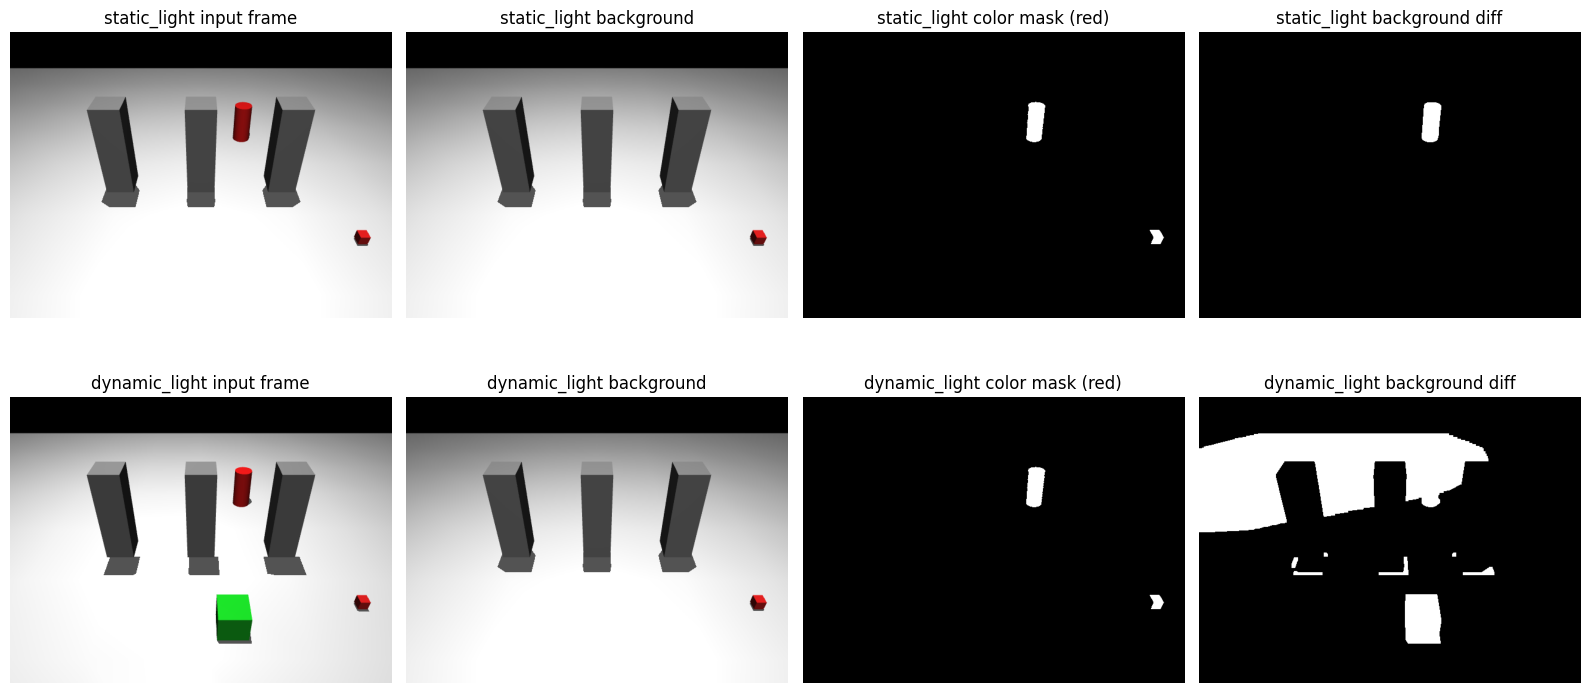

In [29]:
## Main
# Compare color masking and background differencing across both scene conditions.

HSV_RANGES = {'red': ((0, 90, 60), (10, 255, 255))}
BG_DIFF_THRESHOLD = 30
MORPH_KERNEL = np.ones((5, 5), dtype=np.uint8)


def detect_color_mask(frame_bgr, hsv_range):
    hsv = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2HSV)
    return cv2.inRange(hsv, np.array(hsv_range[0], dtype=np.uint8), np.array(hsv_range[1], dtype=np.uint8))


def detect_background_difference_mask(frame_bgr, background_bgr, diff_threshold=30, kernel=MORPH_KERNEL):
    gray_diff = cv2.cvtColor(cv2.absdiff(frame_bgr, background_bgr), cv2.COLOR_BGR2GRAY)
    _, raw_mask = cv2.threshold(gray_diff, diff_threshold, 255, cv2.THRESH_BINARY)
    mask = cv2.morphologyEx(raw_mask, cv2.MORPH_OPEN, kernel)
    return cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)


frame_idx = 60
comparison_inputs = {
    'static_light': (frames_static_rgb[frame_idx], background_static_rgb),
    'dynamic_light': (frames_dynamic_rgb[frame_idx], background_dynamic_rgb),
}

comparison_results = {}
for scene_name, (frame_rgb, background_rgb) in comparison_inputs.items():
    frame_bgr = cv2.cvtColor(frame_rgb, cv2.COLOR_RGB2BGR)
    background_bgr = cv2.cvtColor(background_rgb, cv2.COLOR_RGB2BGR)
    comparison_results[scene_name] = {
        'frame_bgr': frame_bgr,
        'background_bgr': background_bgr,
        'color_mask': detect_color_mask(frame_bgr, HSV_RANGES['red']),
        'bg_mask': detect_background_difference_mask(frame_bgr, background_bgr, diff_threshold=BG_DIFF_THRESHOLD),
    }

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for row, scene_name in enumerate(['static_light', 'dynamic_light']):
    result = comparison_results[scene_name]
    axes[row, 0].imshow(cv2.cvtColor(result['frame_bgr'], cv2.COLOR_BGR2RGB))
    axes[row, 0].set_title(f'{scene_name} input frame')
    axes[row, 1].imshow(cv2.cvtColor(result['background_bgr'], cv2.COLOR_BGR2RGB))
    axes[row, 1].set_title(f'{scene_name} background')
    axes[row, 2].imshow(result['color_mask'], cmap='gray')
    axes[row, 2].set_title(f'{scene_name} color mask (red)')
    axes[row, 3].imshow(result['bg_mask'], cmap='gray')
    axes[row, 3].set_title(f'{scene_name} background diff')
    for col in range(4):
        axes[row, col].axis('off')

plt.tight_layout()
plt.show()


In [30]:
## Main
# Find an optimal min_area values for color-mask detections in the dynamic-light scene.

COLOR_TRACK_MIN_AREA = 400

In [31]:
def extract_detection_from_mask(mask, min_area):
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if len(contours) == 0:
        return None

    contour = max(contours, key=cv2.contourArea)
    area = cv2.contourArea(contour)
    if area < min_area:
        return None

    x, y, w, h = cv2.boundingRect(contour)
    center = np.array([x + w / 2.0, y + h / 2.0], dtype=np.float32)
    return {'bbox': (x, y, w, h), 'center': center, 'area': area}


def draw_detection(frame_bgr, detection, label, color=(0, 0, 255), text_mode='bbox'):
    out = frame_bgr.copy()

    if detection is None:
        text = f'{label}: no detection'
        text_pos = (20, 30)
    else:
        x, y, w, h = detection['bbox']
        cx, cy = detection['center']
        cv2.rectangle(out, (x, y), (x + w, y + h), color, 2)
        cv2.circle(out, (int(cx), int(cy)), 4, color, -1)

        text = f"{label} (area={int(detection['area'])})"
        text_pos = (20, 30) if text_mode == 'top_left' else (x, max(20, y - 8))

    cv2.putText(out, text, text_pos, cv2.FONT_HERSHEY_SIMPLEX, 0.55, color, 2)
    return out


preview_frames = []

for frame_rgb in frames_dynamic_rgb:
    frame_bgr = cv2.cvtColor(frame_rgb, cv2.COLOR_RGB2BGR)
    color_mask = detect_color_mask(frame_bgr, HSV_RANGES['red'])
    detection = extract_detection_from_mask(color_mask, min_area=COLOR_TRACK_MIN_AREA)
    vis = draw_detection(
        frame_bgr,
        detection,
        label=f'threshold={COLOR_TRACK_MIN_AREA}',
        color=(20, 20, 220),
        text_mode='top_left',
    )
    preview_frames.append(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))

print('Color-mask detection preview (dynamic_light):')
media.show_video(preview_frames, fps=30, loop=False)


Color-mask detection preview (dynamic_light):


This browser does not support the video tag.


In [32]:
## Main
# Use color-mask detections from the dynamic-light scene as Kalman measurements.

def make_xy_tracker(initial_xy):
    initial_state = np.array([initial_xy[0], initial_xy[1], 0.0, 0.0], dtype=np.float64)
    initial_covariance = np.eye(4) * 2.0
    measurement_matrix = np.array([[1, 0, 0, 0], [0, 1, 0, 0]], dtype=np.float64)
    measurement_noise_covariance = np.eye(2) * 8.0
    transition_matrix = np.array(
        [[1, 0, 1, 0], [0, 1, 0, 1], [0, 0, 1, 0], [0, 0, 0, 1]],
        dtype=np.float64,
    )
    process_noise_covariance = np.diag([1e-2, 1e-2, 1e-1, 1e-1])
    return KalmanFilter(
        initial_state,
        initial_covariance,
        measurement_matrix,
        measurement_noise_covariance,
        transition_matrix,
        process_noise_covariance,
    )


def draw_tracking_overlay(
    frame_rgb,
    detection,
    tracker,
    detection_color=(0, 0, 255),
    predictor_color=(255, 0, 0),
):
    frame_bgr = cv2.cvtColor(frame_rgb, cv2.COLOR_RGB2BGR)

    if detection is not None:
        x, y, w, h = detection['bbox']
        cx, cy = detection['center']
        cv2.rectangle(frame_bgr, (x, y), (x + w, y + h), detection_color, 2)
        cv2.circle(frame_bgr, (int(cx), int(cy)), 4, detection_color, -1)

    if tracker is not None:
        pred_x, pred_y = tracker.state[:2]
        cv2.circle(frame_bgr, (int(pred_x), int(pred_y)), 6, predictor_color, 2)

    return cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)


def track_with_color(frames_rgb, min_area=COLOR_TRACK_MIN_AREA):
    tracker = None
    output_frames = []
    raw_centers = []
    kalman_centers = []

    for frame_rgb in frames_rgb:
        frame_bgr = cv2.cvtColor(frame_rgb, cv2.COLOR_RGB2BGR)
        mask = detect_color_mask(frame_bgr, HSV_RANGES['red'])
        detection = extract_detection_from_mask(mask, min_area=min_area)

        if detection is not None:
            raw_centers.append(detection['center'].copy())
        else:
            raw_centers.append(np.array([np.nan, np.nan], dtype=np.float32))

        if tracker is None and detection is not None:
            tracker = make_xy_tracker(detection['center'])

        if tracker is not None:
            tracker.predict()
            if detection is not None:
                tracker.update(detection['center'])
            kalman_centers.append(tracker.state[:2].copy())
        else:
            kalman_centers.append(np.array([np.nan, np.nan], dtype=np.float32))

        output_frames.append(draw_tracking_overlay(frame_rgb, detection, tracker))

    return output_frames, np.array(raw_centers), np.array(kalman_centers)


tracked_frames, raw_color, kf_color = track_with_color(frames_dynamic_rgb, min_area=COLOR_TRACK_MIN_AREA)
print('Tracking from color-mask detections (dynamic_light scene):')
media.show_video(tracked_frames, fps=30, loop=False)


Tracking from color-mask detections (dynamic_light scene):


This browser does not support the video tag.


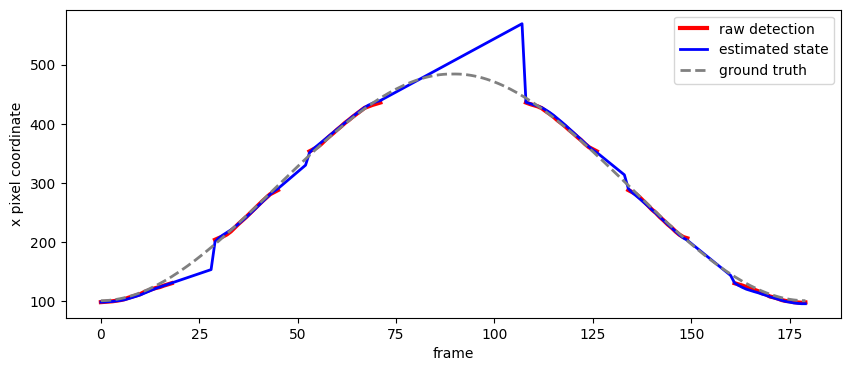

In [33]:
gt_data = np.load(scene_dynamic_gt_path)
gt_world_xy = gt_data['world_xy']

# True ground truth: project the cylinder center (world 3D) into image pixels.
height, width = frames_dynamic_rgb[0].shape[:2]
model = mujoco.MjModel.from_xml_string(get_detection_scene_xml(include_red_object=True, include_green_object=True))
data = mujoco.MjData(model)
mujoco.mj_forward(model, data)

cam_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_CAMERA, 'oblique_top')
cam_pos = np.array(data.cam_xpos[cam_id], dtype=np.float64)
cam_rot = np.array(data.cam_xmat[cam_id], dtype=np.float64).reshape(3, 3)

fovy = np.deg2rad(model.cam_fovy[cam_id])
fy = 0.5 * height / np.tan(0.5 * fovy)
fx = fy

gt_world_xyz = np.column_stack([
    gt_world_xy[:, 0],
    gt_world_xy[:, 1],
    np.full(len(gt_world_xy), OBJECT_Z, dtype=np.float64),
])

gt_cam = (cam_rot.T @ (gt_world_xyz - cam_pos).T).T
x_cam = gt_cam[:, 0]
z_cam = gt_cam[:, 2]

depth = -z_cam
visible = depth > 1e-9

gt_x_pixel = np.full(len(gt_world_xyz), np.nan, dtype=np.float64)
gt_x_pixel[visible] = (width / 2.0) + fx * (x_cam[visible] / depth[visible])

plt.figure(figsize=(10, 4))
plt.plot(raw_color[:, 0], linewidth=3, c='red', label='raw detection')
plt.plot(kf_color[:, 0], linewidth=2, c='blue', label='estimated state')
plt.plot(gt_x_pixel, '--', linewidth=2, c='gray', label='ground truth')
plt.xlabel('frame')
plt.ylabel('x pixel coordinate')
plt.legend()
plt.show()


### Tasks
1. Compare color segmentation and background differencing in both `static_light` and `dynamic_light` scenes. For each scene, state which method is more reliable and explain why based on the observed failure modes. Also identify the key assumptions each method relies on (e.g., camera/background consistency).
2. Tune the minimum detected-region size threshold (pixel area) so the small red cube is always rejected while the target red cylinder remains detected (unless it is occluded). Then discuss the limitations of relying on a fixed, pre-defined threshold and propose potential countermeasures to mitigate them.
3. Implement the Kalman update step and track the red cylinder. Compare raw detections with the Kalman estimate, and discuss when filtering helps and when it still struggles.
4. *(Optional)* Try a modern deep-learning detector/segmenter, such as [YOLO](https://github.com/ultralytics/ultralytics) (for object detection) or [SAM 3](https://github.com/facebookresearch/sam3) (for promptable segmentation), on a photo or short video clip of an arbitrary object of your choice.


### Answers
1. Static light: Background differencing wins. With constant lighting, only the moving cylinder differs from the background. Color masking also falsely detects the static red cube.
Dynamic light: Color segmentation wins. Background differencing fails because moving light shifts shadows/brightness (flagged as false changes), and the green box isn't in the reference background. Color masking ignores lighting as long as the hue is stable.
Assumptions: Color masking assumes a unique, consistent target color. Background differencing assumes a fixed camera, static background, and constant illumination.
2. Set COLOR_TRACK_MIN_AREA = 400: large enough to reject the small red cube, small enough to keep the cylinder.
Limitations: Apparent size depends on camera distance/zoom, so it breaks if the camera moves; partial occlusion can shrink the cylinder below the threshold; the value is hand-tuned and won't generalize.
Countermeasures: Use a relative threshold (fraction of frame area), adapt it from recent detections, or add shape cues (aspect ratio, circularity).
3. The update step fuses noisy measurements with the motion prediction — the blue estimate is smoother than the red raw detection and tracks ground truth well.
Helps: Suppresses jitter; coasts through short occlusions using predict() alone.
Struggles: Long occlusions (velocity drifts, uncertainty grows), turning points (constant-velocity model lags), and false detections from the red cube pulling the estimate off-target.